In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

In [2]:
def juego(numero_rondas: int, rule: str = "override", seed: int = 42):
    
    rng = np.random.default_rng(seed)

    d1 = rng.integers(1, 7, size=numero_rondas)
    d2 = rng.integers(1, 7, size=numero_rondas)
    s = d1 + d2

    base_payoff = np.where(s >= 7, 10, -8)

    is_repeat = np.zeros(numero_rondas, dtype=bool)
    is_repeat[1:] = s[1:] == s[:-1]

    if rule == "override":
        payoff = np.where(is_repeat, -15, base_payoff)
    elif rule == "additive":
        payoff = base_payoff + np.where(is_repeat, -15, 0)
    else:
        raise ValueError("rule debe ser 'override' o 'additive'")

    cum_profit = np.cumsum(payoff)

    df = pd.DataFrame({
        "round": np.arange(1, numero_rondas + 1),
        "d1": d1,
        "d2": d2,
        "sum": s,
        "is_repeat": is_repeat,
        "base_payoff": base_payoff,
        "payoff": payoff,
        "cum_profit": cum_profit,
    })
    return df

In [3]:
N = 10000
RULE = "override"

df = juego(N, rule=RULE, seed=SEED)

df.head()

,round,d1,d2,sum,is_repeat,base_payoff,payoff,cum_profit
0,1,1,3,4,False,-8,-8,-8
1,2,5,2,7,False,10,10,2
2,3,4,4,8,False,10,10,12
3,4,3,4,7,False,10,10,22
4,5,3,2,5,False,-8,-8,14


In [4]:
summary = {
    "Rondas simuladas": len(df),
    "Ganancia promedio por ronda ($)": df["payoff"].mean(),
    "Desv. estándar por ronda ($)": df["payoff"].std(ddof=0),
    "Probabilidad de repetición": df["is_repeat"].mean(),
    "Ganancia total final ($)": df["cum_profit"].iloc[-1],
}

pd.DataFrame([summary]).T

,0
Rondas simuladas,10000.000000
Ganancia promedio por ronda ($),0.239800
Desv. estándar por ronda ($),10.018588
Probabilidad de repetición,0.114000
Ganancia total final ($),2398.000000


In [5]:
mean_payoff = df["payoff"].mean()
repeat_rate = df["is_repeat"].mean()
final_profit = df["cum_profit"].iloc[-1]

print(f"Ganancia promedio por ronda: {mean_payoff:.4f} $/ronda")
print(f"Tasa de repetición: {repeat_rate:.4%}")
print(f"Ganancia total: {final_profit:,.0f} $")

if mean_payoff > 0:
    print("\nRecomendación: Sí conviene jugar EN PROMEDIO")
    print("a pocas rondas puedes perder por rachas de repetición")
else:
    print("\nRecomendación: No conviene jugar EN PROMEDIO")
    print("La penalización por repetición hace el juego desfavorable")

Ganancia promedio por ronda: 0.2398 $/ronda
Tasa de repetición: 11.4000%
Ganancia total: 2,398 $

Recomendación: Sí conviene jugar EN PROMEDIO
a pocas rondas puedes perder por rachas de repetición


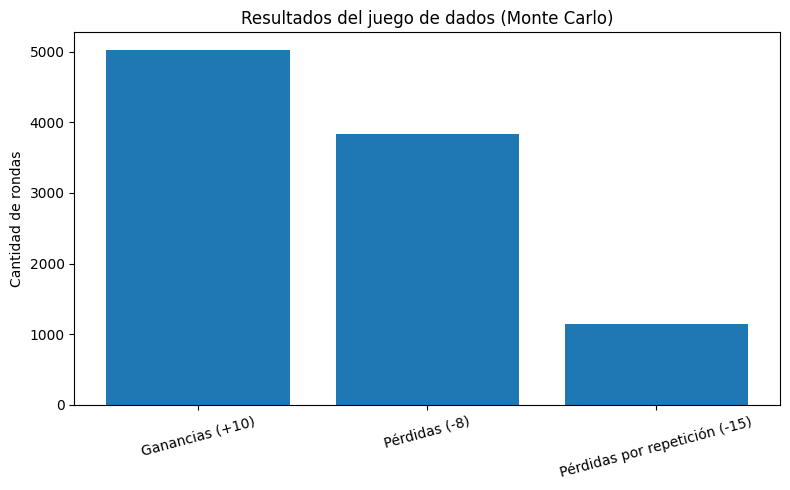

Ganancias: 5021
Pérdidas normales: 3839
Pérdidas por repetición: 1140


In [6]:
# Clasificar resultados
ganancias = (df["payoff"] == 10).sum()
perdidas = (df["payoff"] == -8).sum()
perdidas_repetidas = (df["payoff"] == -15).sum()

labels = ["Ganancias (+10)", 
          "Pérdidas (-8)", 
          "Pérdidas por repetición (-15)"]

valores = [ganancias, perdidas, perdidas_repetidas]

plt.figure(figsize=(8,5))
plt.bar(labels, valores)
plt.ylabel("Cantidad de rondas")
plt.title("Resultados del juego de dados (Monte Carlo)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Ganancias:", ganancias)
print("Pérdidas normales:", perdidas)
print("Pérdidas por repetición:", perdidas_repetidas)